전체 데이터 수량: 12970
로드된 컬럼 목록: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Transported와 가장 관련성이 높은 항목: CryoSleep (상관계수: 0.4686)


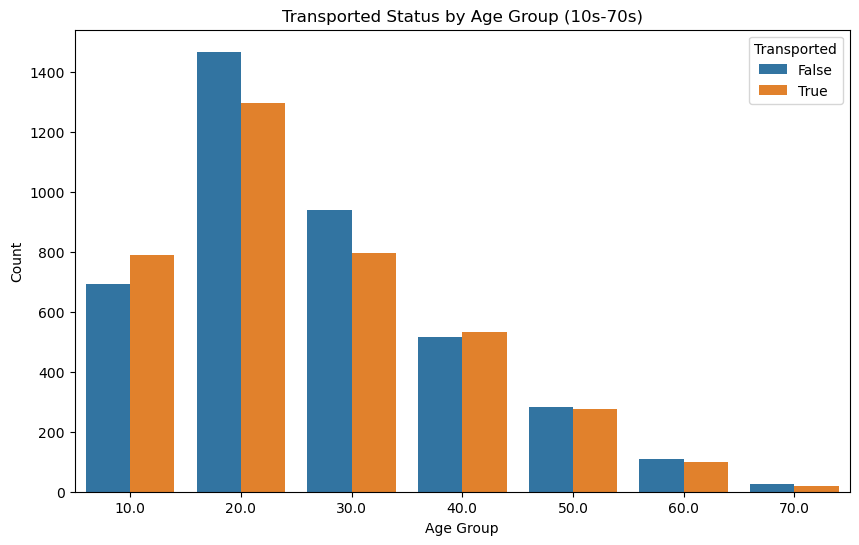

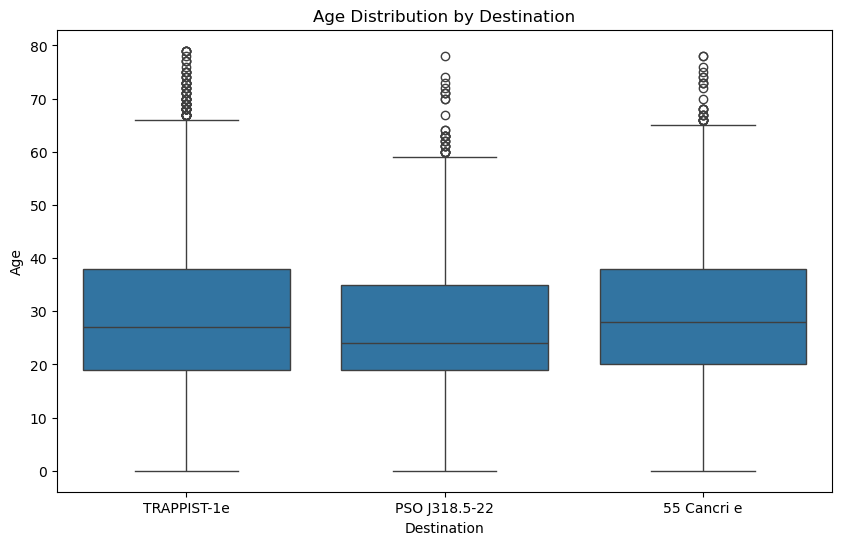

In [28]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 메시지 출력 방지
warnings.filterwarnings('ignore')

def load_and_merge_data():
    """
    train.csv와 test.csv를 읽어 하나로 병합하고 전체 데이터 수를 출력하는 함수
    """
    try:
        train_df = pd.read_csv('train.csv')
        test_df = pd.read_csv('test.csv')
    except FileNotFoundError:
        print("Error: 'train.csv' 또는 'test.csv' 파일을 찾을 수 없습니다.")
        return None

    # 두 데이터 병합
    merged_df = pd.concat([train_df, test_df], ignore_index=True)
    
    # [수정] 컬럼명 앞뒤 공백 제거 (데이터 오류 방지)
    merged_df.columns = merged_df.columns.str.strip()

    print(f'전체 데이터 수량: {len(merged_df)}')
    print(f'로드된 컬럼 목록: {list(merged_df.columns)}') # 디버깅용 출력
    
    return merged_df

def find_highest_correlation(df):
    """
    Transported 항목과 가장 관련성이 높은 항목을 찾는 함수
    """
    # [수정] Transported 컬럼 존재 여부 선검사
    if 'Transported' not in df.columns:
        print("\n[Critical Error] 'Transported' 컬럼이 데이터에 없습니다.")
        print("train.csv 파일이 올바른지(정답 레이블이 포함되어 있는지) 확인하십시오.")
        return

    corr_df = df.copy()
    
    # Transported가 NaN인 행(Test 데이터) 제거
    corr_df = corr_df.dropna(subset=['Transported'])
    
    if len(corr_df) == 0:
        print("\n[Error] Transported 값이 있는 데이터가 없습니다. train.csv를 확인하세요.")
        return

    # Boolean 타입 처리 (True/False -> 1/0)
    bool_cols = ['CryoSleep', 'VIP', 'Transported']
    for col in bool_cols:
        if col in corr_df.columns:
            # 결측치가 있을 경우를 대비해 fillna 혹은 drop 처리가 필요할 수 있음.
            # 여기서는 상관계수 계산을 위해 변환만 수행
            corr_df[col] = corr_df[col].map({True: 1, False: 0})
            
    # 수치형 데이터만 선택하여 상관관계 계산
    numeric_df = corr_df.select_dtypes(include=['number'])
    
    # Transported와의 상관계수 계산 (절대값 기준 정렬)
    corr_series = numeric_df.corr()['Transported'].abs().sort_values(ascending=False)
    
    if len(corr_series) < 2:
         print("상관관계를 계산할 다른 수치형 컬럼이 부족합니다.")
         return

    # 자기 자신(Transported)을 제외한 가장 높은 상관계수를 가진 항목 추출
    most_relevant = corr_series.index[1] 
    highest_val = corr_series.iloc[1]
    
    print(f'\nTransported와 가장 관련성이 높은 항목: {most_relevant} (상관계수: {highest_val:.4f})')

def visualize_age_transported(df):
    """
    나이를 기준으로 10대~70대별 Transported 여부를 그래프로 출력하는 함수
    """
    if 'Transported' not in df.columns or 'Age' not in df.columns:
        print("시각화에 필요한 컬럼(Age, Transported)이 부족합니다.")
        return

    viz_df = df.copy()
    
    # 나이 결측치 제거 및 10대~70대 필터링
    viz_df = viz_df.dropna(subset=['Age', 'Transported'])
    viz_df = viz_df[(viz_df['Age'] >= 10) & (viz_df['Age'] < 80)]
    
    # 연령대 그룹화
    viz_df['AgeGroup'] = (viz_df['Age'] // 10) * 10
    
    plt.figure(figsize=(10, 6))
    sns.countplot(data=viz_df, x='AgeGroup', hue='Transported')
    
    plt.title('Transported Status by Age Group (10s-70s)')
    plt.xlabel('Age Group')
    plt.ylabel('Count')
    plt.legend(title='Transported')
    plt.show()

def visualize_destination_age_dist(df):
    """
    보너스 과제: Destination 별 승객들의 연령대 분포 시각화
    """
    viz_df = df.copy()
    
    if 'Destination' not in viz_df.columns or 'Age' not in viz_df.columns:
        return

    viz_df = viz_df.dropna(subset=['Age', 'Destination'])
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=viz_df, x='Destination', y='Age')
    
    plt.title('Age Distribution by Destination')
    plt.xlabel('Destination')
    plt.ylabel('Age')
    plt.show()

# 메인 실행 블록
if __name__ == '__main__':
    dataset = load_and_merge_data()
    
    if dataset is not None:
        find_highest_correlation(dataset)
        visualize_age_transported(dataset)
        visualize_destination_age_dist(dataset)